# Train and Test a DNN model using Tensorflow


## Import Libraries

In [113]:
import pandas as pd
import numpy as np

# Scikit-learn is used for preprocessing and splitting the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras is used to build the neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For plotting training history and predictions
import matplotlib.pyplot as plt

## Load Dataset

In [114]:
# Load Monthly Total Data From Github
df = pd.read_csv("https://raw.githubusercontent.com/bcroman/21006366_DA_Assessment/refs/heads/main/Data/monthly_totals.csv")

# Show the head of Data
print("Head of Dataset:")
print(df.head())

# Show Columns with missing data
print("\nColumns with Missing Data:")
print(df.isna().sum())

Head of Dataset:
   year  month crime_month  total_crime   avg_temp   avg_dewp  avg_slp  \
0  2014      1  2014-01-01        55515  44.593548  40.448387      NaN   
1  2014      2  2014-02-01        51222  45.417857  38.946429      NaN   
2  2014      3  2014-03-01        57669  48.122581  39.500000      NaN   
3  2014      4  2014-04-01        53467  52.870000  43.993333      NaN   
4  2014      5  2014-05-01        56327  56.645161  46.748387      NaN   

   avg_visib   avg_wdsp  avg_mxpsd    avg_gust  avg_max_temp  avg_min_temp  \
0   5.974194   9.367742  16.232258  466.096774     50.074194     38.551613   
1   6.542857  12.246429  20.125000  308.460714     51.110714     39.592857   
2  37.709677   7.651613  13.958065  716.606452     57.522581     39.906452   
3   5.813333   7.263333  12.493333  804.816667     61.073333     44.896667   
4  38.387097   7.832258  13.135484  591.487097     64.390323     48.816129   

   avg_prcp  avg_sndp  fog_days month_factor  
0  0.188065       NaN 

## Clean Data

In [115]:
# Target Column to Predict
target_column = "total_crime"

# Select columns to drop from the dataset
columns_to_drop = ["crime_month", "avg_sndp", "avg_slp", "month_factor"]

# Filter out columns that don't exist in df to prevent KeyError on repeated execution
columns_existing_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_existing_to_drop)

# Sepaate input features (X) and target (Y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Covennt all data to float32
X = X.astype("float32")
y = y.astype("float32")

# Print Target and Feature Columns
print("Target Column:")
print(target_column)

print("\nFeature Columns:")
print(X.columns.tolist())

Target Column:
total_crime

Feature Columns:
['year', 'month', 'avg_temp', 'avg_dewp', 'avg_visib', 'avg_wdsp', 'avg_mxpsd', 'avg_gust', 'avg_max_temp', 'avg_min_temp', 'avg_prcp', 'fog_days']


## Split The Data
Traing Set = used for learn patterns  
Test Set = used to evaluate how well the models works

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% of the data goes to testing
    random_state=42     # keeps the split reproducible
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (28, 12)
Test set shape: (8, 12)


## Scale the Input Features
Neural networks usually trin better when numeric features are scaled.  
Standard scaler transforms each column so it have mean is 0 and std is 1.

In [117]:
scaler = StandardScaler()

# Fit the scaler on the training data and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

## Build the DNN model
Using a simpler model version becuase the dataset is small (36 rows)

In [118]:
model = keras.Sequential([
    # Input layer: number of features must match X_train_scaled.shape[1]
    keras.Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer
    layers.Dense(64, activation="relu"),

    # Second hidden layer
    layers.Dense(32, activation="relu"),

    # Output layer
    layers.Dense(1)
])

# Print the model structure
print("\nModel summary:")
model.summary()


Model summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile The Model
Optimizer = 'adam' is a common optimizer  
loss = 'mse' is mean squared error  
metrics= ["mae"] means to track mean absolute error



In [119]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Add Early Stopping
Early stopping stops the training validation performance stops improving which can help reduce overfitting.

In [120]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",         # watch validation loss
    patience=20,                # wait 20 loops before stopping
    restore_best_weights=True   # keep the best weights found
)

## Train The Model
Validation split = 0.2: which means,  
from the training set, 20% is used as validation data  
epochs is the max number of training passes over the data  
batch size is how many rows are used before updating weights

In [121]:
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=300,
    batch_size=4,
    callbacks=[early_stopping]
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.7307 - mae: 0.6562 - val_loss: 0.9069 - val_mae: 0.7871
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5266 - mae: 0.5442 - val_loss: 0.8422 - val_mae: 0.7772
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3624 - mae: 0.4608 - val_loss: 0.7692 - val_mae: 0.7230
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2731 - mae: 0.4012 - val_loss: 0.7579 - val_mae: 0.7310
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2095 - mae: 0.3458 - val_loss: 0.7553 - val_mae: 0.7314
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1651 - mae: 0.3127 - val_loss: 0.7321 - val_mae: 0.7211
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1425 - mae: 0.2901 - val_loss: 0.7244 - val_mae: 0.7170
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1207 - mae: 0.2728 - val_loss: 0.7125 - val_mae: 0.7088
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1016 - mae: 

## Make Predictions

In [122]:
# The model outputs a prediction for each test example
predictions_scaled = model.predict(X_test_scaled)
predictions = scaler.inverse_transform(predictions_scaled).flatten()

# Show Results
print("\nActual vs Predicted:")
for actual, predicted in zip(y_test.values, predictions):
    print(f"Actual: {actual:.0f} | Predicted: {predicted:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Actual vs Predicted:
Actual: 62455 | Predicted: 64873.81
Actual: 53316 | Predicted: 57529.84
Actual: 59167 | Predicted: 59791.95
Actual: 65519 | Predicted: 62312.97
Actual: 61038 | Predicted: 58033.92
Actual: 62666 | Predicted: 61958.93
Actual: 62361 | Predicted: 60242.10
Actual: 57055 | Predicted: 55345.51


## Evaluate The Model

In [123]:
# Calculate metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

# Print nicely
print("Model Evaluation:")
print("------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation:
------------------
MAE  : 2250.40
MSE  : 6401598.00
RMSE : 2530.14
R²   : 0.5013


## Plot Predictions vs Actual

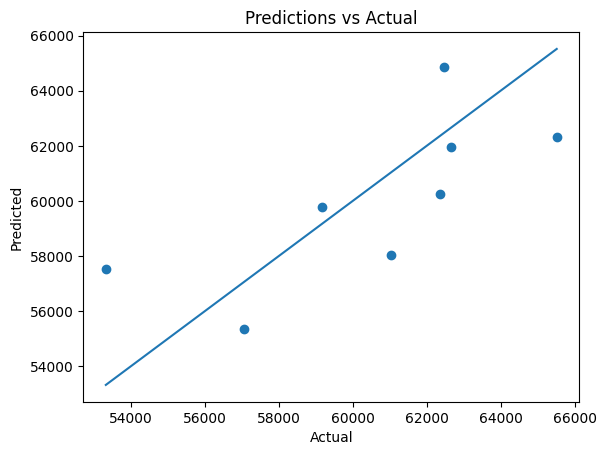

In [124]:
# If the model were perfect, all points would lie exactly on the diagonal line.
plt.figure()
plt.scatter(y_test, predictions)

# Perfect prediction line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predictions vs Actual")
plt.show()